# Fase 3 — Preparación de los Datos
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Combina **dos fuentes** y produce un conjunto limpio, balanceado y dividido,
con **estimación de tamaño** por segmentación:

- **Kaggle** (`data/external`): Good→Premium, Bad→Descarte. La carpeta **Mixed se
  EXCLUYE** (varias frutas por foto, fondo no uniforme → se reserva para el
  ejercicio de segmentación).
- **Dataset propio** (`data/raw`): Good→Premium, **Regular→Estándar**, Bad→Descarte.

La clase **Estándar** proviene ahora de imágenes propias *Regular* (1 fruta por
foto), reemplazando al antiguo "Mixed".

Pasos: (1) carga combinada, (2) **cap por fruta×calidad** (corrige sesgo
Pomegranate, EDA §2.3), (3) **split agrupado anti-fuga** 70/15/15, (4) tamaño,
(5) guardado.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

from src.config import (QUALITY_CLASSES, SIZE_CLASSES, CAP_PER_FRUIT_QUALITY,
                        FIGURES_DIR, PROCESSED_DIR)
from src.data import preprocessing as prep
from src.data.segmentation import segment_fruit
from src.data.paths import load_image_rgb
print("Repo:", ROOT)

Repo: /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier


## 1. Carga combinada (Kaggle sin Mixed + dataset propio)

In [2]:
raw = prep.load_combined_labels()
print("\n[quality × source]")
print(pd.crosstab(raw['quality'], raw['source']).reindex(QUALITY_CLASSES))
print("\n[fruta × calidad]")
print(pd.crosstab(raw['fruit'], raw['quality']).reindex(columns=QUALITY_CLASSES))

[load] Kaggle=18452 | Propio=6859 | Total=25311
source    kaggle  propio
quality                 
Descarte    6788    1046
Estándar    1068    4612
Premium    10596    1201

[quality × source]
source    kaggle  propio
quality                 
Premium    10596    1201
Estándar    1068    4612
Descarte    6788    1046

[fruta × calidad]
quality      Premium  Estándar  Descarte
fruit                                   
Apple           1264      1027      1294
Banana           969      1296      1771
Guava           1091      1074      1264
Lime            1261       776      1159
Orange          1362       570      1159
Pomegranate     5850       937      1187


## 2. Balanceo por *cap* (fruta × calidad)
El EDA (§2.3) detectó que **Pomegranate_Good** inflaba la clase Premium. Capeando
por *fruta × calidad* evitamos que una sola fruta domine una clase y reducimos el
desbalanceo. El residual lo absorbe `class_weight='balanced'`.

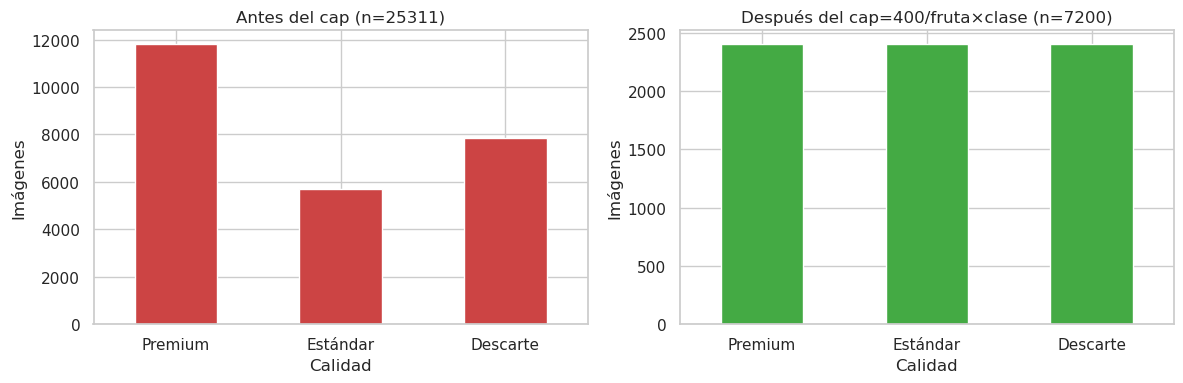

Composición de Premium por fruta (antes vs después):
             antes  después
fruit                      
Pomegranate  0.496    0.167
Orange       0.115    0.167
Apple        0.107    0.167
Lime         0.107    0.167
Guava        0.092    0.167
Banana       0.082    0.167


In [3]:
capped = prep.apply_cap(raw)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
raw['quality'].value_counts().reindex(QUALITY_CLASSES).plot.bar(
    ax=ax[0], color="#c44", title=f"Antes del cap (n={len(raw)})")
capped['quality'].value_counts().reindex(QUALITY_CLASSES).plot.bar(
    ax=ax[1], color="#4a4", title=f"Después del cap={CAP_PER_FRUIT_QUALITY}/fruta×clase (n={len(capped)})")
for a in ax: a.set_xlabel("Calidad"); a.set_ylabel("Imágenes"); a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase3_balanceo.pdf", bbox_inches="tight"); plt.show()
print("Composición de Premium por fruta (antes vs después):")
print(pd.concat([
    raw[raw.quality=='Premium']['fruit'].value_counts(normalize=True).round(3).rename('antes'),
    capped[capped.quality=='Premium']['fruit'].value_counts(normalize=True).round(3).rename('después'),
], axis=1))

## 3. Anti-fuga + split agrupado 70/15/15
El dataset trae **ráfagas de la misma fruta** (Kaggle y propio). Un split aleatorio
filtraría fotos casi idénticas entre train y test → **fuga de datos**. Lo evitamos:
agrupamos casi-duplicados con *perceptual hash* (dHash + Hamming ≤ 5) → `group_id`,
y hacemos el split **por grupo** dentro de cada clase.

In [4]:
from src.data.dedup import assign_groups
capped = capped.copy()
capped['group_id'] = assign_groups(capped['abs_path'].tolist())
print(f"{len(capped)} imágenes -> {capped['group_id'].nunique()} grupos")

split_df = prep.grouped_split(capped)
print(pd.crosstab(split_df['quality'], split_df['split']).reindex(QUALITY_CLASSES)[['train','val','test']])
span = split_df.groupby('group_id')['split'].nunique()
print(f"\nGrupos que cruzan >1 split (debe ser 0): {(span>1).sum()}")

dhash:   0%|          | 0/7200 [00:00<?, ?it/s]

7200 imágenes -> 6223 grupos


split     train  val  test
quality                   
Premium    1682  353   365
Estándar   1700  342   358
Descarte   1684  363   353

Grupos que cruzan >1 split (debe ser 0): 0


## 4. Estimación de tamaño por segmentación (C1)
Diámetro equivalente normalizado por la diagonal, discretizado en terciles
aprendidos **solo en train**. Ejecuta el pipeline completo y guarda los manifests.

In [5]:
df = prep.build_manifests()
thr = df.attrs['size_thresholds']
print(f"\nUmbrales de tamaño: Pequeño < {thr[0]:.3f} ≤ Mediano < {thr[1]:.3f} ≤ Grande")
print("\n[quality × split]")
print(pd.crosstab(df['quality'], df['split']).reindex(QUALITY_CLASSES)[['train','val','test']])

[load] Kaggle=18452 | Propio=6859 | Total=25311
source    kaggle  propio
quality                 
Descarte    6788    1046
Estándar    1068    4612
Premium    10596    1201
[labels] /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier/data/annotations/labels.csv regenerado: 25311 filas, esquema único


dhash:   0%|          | 0/7200 [00:00<?, ?it/s]

segmentando:   0%|          | 0/7200 [00:00<?, ?it/s]

mixed-seg:   0%|          | 0/1074 [00:00<?, ?it/s]

[mixed] 1525 recortes de enriquecimiento añadidos a train
{'Descarte': 846, 'Estándar': 494, 'Premium': 185}
[build] manifests guardados en /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier/data/processed (cache de features invalidado)

Umbrales de tamaño: Pequeño < 0.245 ≤ Mediano < 0.372 ≤ Grande

[quality × split]
split     train  val  test
quality                   
Premium    1867  353   365
Estándar   2194  342   358
Descarte   2530  363   353


### 4.1 Distribución de diámetro y clases de tamaño

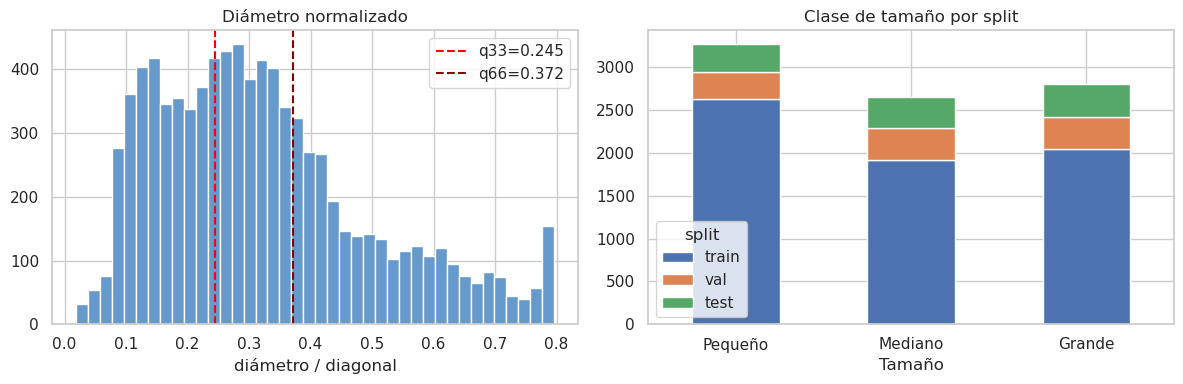

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['diameter_norm'].dropna(), bins=40, color="#69c", edgecolor="white")
ax[0].axvline(thr[0], color="red", ls="--", label=f"q33={thr[0]:.3f}")
ax[0].axvline(thr[1], color="darkred", ls="--", label=f"q66={thr[1]:.3f}")
ax[0].set_title("Diámetro normalizado"); ax[0].set_xlabel("diámetro / diagonal"); ax[0].legend()
pd.crosstab(df['size'], df['split']).reindex(SIZE_CLASSES)[['train','val','test']].plot.bar(ax=ax[1], stacked=True)
ax[1].set_title("Clase de tamaño por split"); ax[1].set_xlabel("Tamaño"); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase3_tamano.pdf", bbox_inches="tight"); plt.show()

### 4.2 Ejemplo visual de segmentación

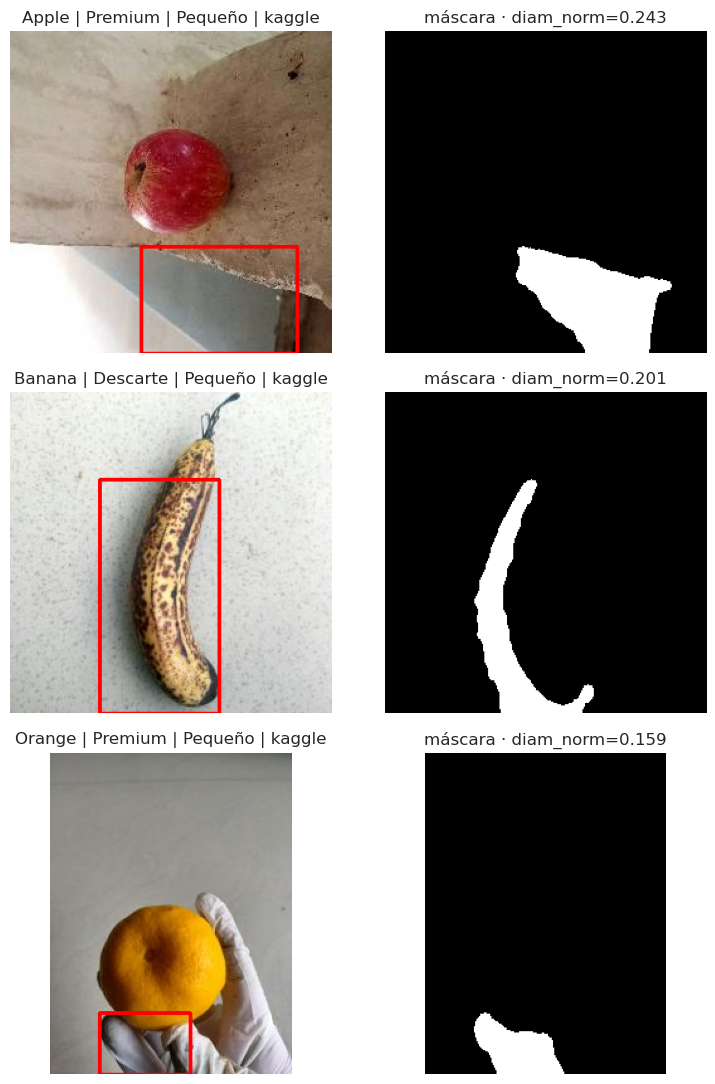

In [7]:
import cv2
samples = df.sample(3, random_state=7)
fig, axes = plt.subplots(3, 2, figsize=(8, 11))
for i, (_, row) in enumerate(samples.iterrows()):
    img = load_image_rgb(row['abs_path']); seg = segment_fruit(img)
    x,y,w,h = seg.bbox; vis = img.copy()
    cv2.rectangle(vis, (x,y), (x+w,y+h), (255,0,0), max(2, img.shape[1]//150))
    axes[i,0].imshow(vis); axes[i,0].set_title(f"{row['fruit']} | {row['quality']} | {row['size']} | {row['source']}")
    axes[i,1].imshow(seg.mask, cmap='gray'); axes[i,1].set_title(f"máscara · diam_norm={seg.diameter_norm:.3f}")
    for a in axes[i]: a.axis('off')
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase3_segmentacion_ejemplos.pdf", bbox_inches="tight"); plt.show()

## 4.3 Enriquecimiento con la carpeta Mixed (segmentación multi-fruta)
La carpeta Kaggle **Mixed** tiene varias frutas por foto. La **segmentamos en
recortes individuales** (cumple el requisito del enunciado) y los re-etiquetamos
por **daño superficial (heurística NTC-4580)**. Estos recortes se añaden **solo a
train** (nunca val/test) → enriquecen el entrenamiento sin meter etiquetas
derivadas de color en la evaluación (evita métricas circulares).

Composición de TRAIN por fuente:
source    kaggle  mixed_seg  propio
quality                            
Premium     1446        185     236
Estándar     287        494    1413
Descarte    1478        846     206


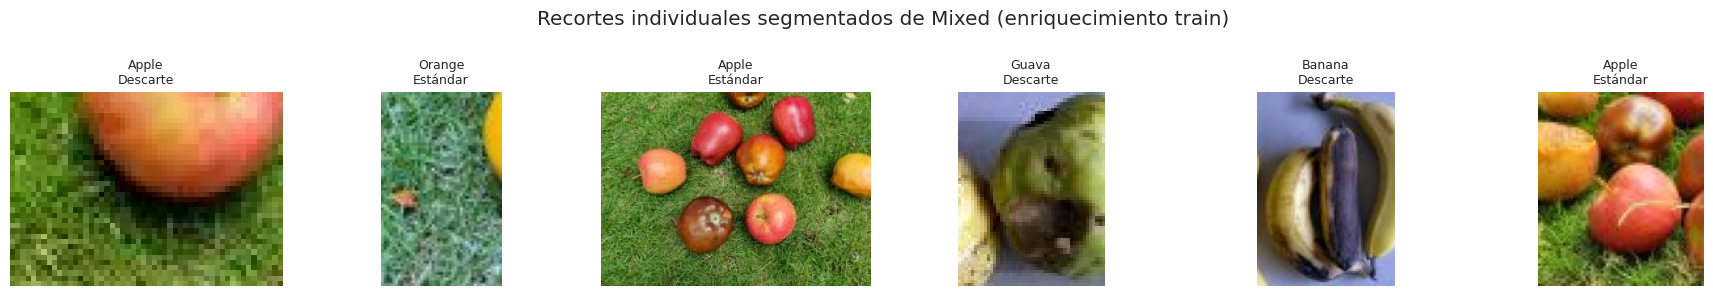

In [8]:
print("Composición de TRAIN por fuente:")
tr = df[df['split']=='train']
print(pd.crosstab(tr['quality'], tr['source']).reindex(QUALITY_CLASSES))
# Ejemplos de recortes segmentados de Mixed
import cv2
seg = df[df['source']=='mixed_seg']
if len(seg):
    s = seg.sample(min(6, len(seg)), random_state=1)
    fig, axes = plt.subplots(1, len(s), figsize=(3*len(s), 3))
    if len(s)==1: axes=[axes]
    for ax,(_,r) in zip(axes, s.iterrows()):
        ax.imshow(load_image_rgb(r['abs_path'])); ax.axis('off')
        ax.set_title(f"{r['fruit']}\n{r['quality']}", fontsize=9)
    plt.suptitle("Recortes individuales segmentados de Mixed (enriquecimiento train)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase3_mixed_segmentado.pdf", bbox_inches="tight"); plt.show()

## 5. Auditoría de label-noise (NTC-4580, umbral de daño por especie)
Aplicamos la heurística de daño a una muestra de **cada clase** para cuantificar:
- En **Premium/Descarte** (etiqueta de carpeta): qué fracción "re-etiquetaría" el
  daño → estimación de *label noise* y verificación del **piso de clase** (un
  Descarte no debería volverse Premium).
- En **Mixed**: cómo se reparte el daño en Premium/Estándar/Descarte.
Usa el umbral de daño **por especie** (FIX-PER-FRUIT: Banana 35, Pomegranate 40).

Umbral 'oscuro' por especie: {'Banana': 35, 'Pomegranate': 40} | resto=55


[load] Kaggle=18452 | Propio=6859 | Total=25311
source    kaggle  propio
quality                 
Descarte    6788    1046
Estándar    1068    4612
Premium    10596    1201



── Auditoría por clase de origen → etiqueta según daño ──
  Premium   (n=300): {'Descarte': 90.0, 'Estándar': 9.0, 'Premium': 1.0}
     → label noise estimado (no-Premium): 99.0%
  Descarte  (n=300): {'Descarte': 96.0, 'Estándar': 4.0}
     → piso de clase: 0.0% ascendió a Premium (OK)
  Mixed     (n=599): {'Descarte': 71.6, 'Estándar': 20.0, 'Premium': 8.3}


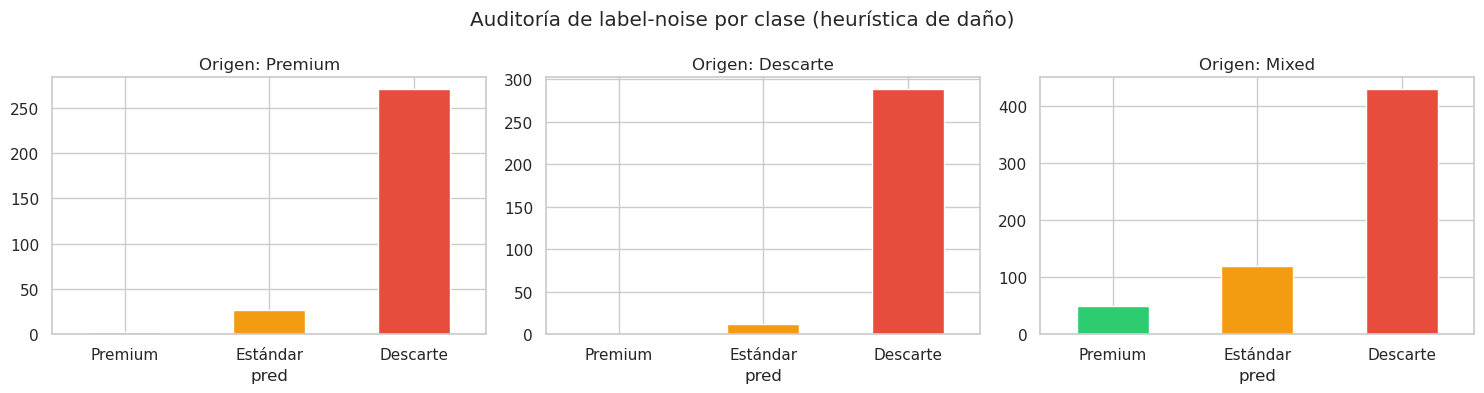

In [9]:
from src.data.preprocessing import load_combined_labels
from src.data.segmentation import (segment_instances, compute_damage_pct,
                                    assign_quality_by_damage, FRUIT_DARK_V_THRESHOLD)
from src.config import EXTERNAL_DIR, MIXED_DIRNAME
print("Umbral 'oscuro' por especie:", FRUIT_DARK_V_THRESHOLD, "| resto=55")

cat = load_combined_labels()
def audit(sample_df, allow_multiple):
    recs=[]
    for _,r in sample_df.iterrows():
        im=load_image_rgb(r['abs_path']) if 'abs_path' in r else load_image_rgb(r['path'])
        if im is None: continue
        ins=segment_instances(im, allow_multiple=allow_multiple, fruit_name=r['fruit'])
        if not ins: continue
        for i in ins:
            recs.append({'fruit':r['fruit'],'origin':r['quality'],
                         'damage':i['damage_pct'],
                         'pred':assign_quality_by_damage(i['damage_pct'])})
    return pd.DataFrame(recs)

audit_rows=[]
for q in ['Premium','Descarte']:
    s=cat[cat['quality']==q].sample(min(300,len(cat[cat['quality']==q])),random_state=1)
    a=audit(s, allow_multiple=False); a['origin']=q; audit_rows.append(a)
# Mixed desde carpeta
import pandas as pd
mix=[{'fruit':p.parent.name.split('_')[0],'quality':'Mixed','path':str(p)}
     for p in (EXTERNAL_DIR/MIXED_DIRNAME).rglob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png'}]
mixdf=pd.DataFrame(mix).sample(min(300,len(mix)),random_state=1)
am=audit(mixdf, allow_multiple=True); am['origin']='Mixed'; audit_rows.append(am)
A=pd.concat(audit_rows, ignore_index=True)

print("\n── Auditoría por clase de origen → etiqueta según daño ──")
for q in ['Premium','Descarte','Mixed']:
    sub=A[A['origin']==q]
    if not len(sub): continue
    dist=sub['pred'].value_counts(normalize=True).mul(100).round(1).to_dict()
    print(f"  {q:9s} (n={len(sub)}): {dist}")
    if q=='Premium':
        print(f"     → label noise estimado (no-Premium): {100*(sub['pred']!='Premium').mean():.1f}%")
    if q=='Descarte':
        viol=100*(sub['pred']=='Premium').mean()
        print(f"     → piso de clase: {viol:.1f}% ascendió a Premium ({'OK' if viol<2 else 'revisar'})")
fig,ax=plt.subplots(1,3,figsize=(15,4))
for a_,q in zip(ax,['Premium','Descarte','Mixed']):
    sub=A[A['origin']==q]['pred'].value_counts().reindex(QUALITY_CLASSES).fillna(0)
    sub.plot.bar(ax=a_, color=['#2ecc71','#f39c12','#e74c3c']); a_.set_title(f"Origen: {q}"); a_.tick_params(axis='x',rotation=0)
plt.suptitle("Auditoría de label-noise por clase (heurística de daño)")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase3_label_noise_audit.pdf", bbox_inches="tight"); plt.show()

## 6. Validaciones de integridad
Aserciones automáticas que garantizan un dataset sano antes de modelar.

In [10]:
tr=df[df['split']=='train']; va=df[df['split']=='val']; te=df[df['split']=='test']

# 6.1 Anti-fuga: ningún grupo de casi-duplicados cruza particiones
span=df.groupby('group_id')['split'].nunique()
assert (span>1).sum()==0, "FUGA: hay grupos en más de un split"
print("✓ Anti-fuga: 0 grupos cruzan train/val/test")

# 6.2 Enriquecimiento Mixed solo en train (no en val/test)
assert (va['source']=='mixed_seg').sum()==0 and (te['source']=='mixed_seg').sum()==0, \
    "Hay recortes mixed_seg en val/test"
print("✓ mixed_seg solo en train (val/test con etiquetas limpias)")

# 6.3 Sin NaN en columnas clave
for col in ['quality','quality_idx','fruit','source','size','split']:
    assert df[col].notna().all(), f"NaN en columna {col}"
print("✓ Sin valores nulos en columnas clave")

# 6.4 Todas las clases presentes en cada split
for nm,d_ in [('train',tr),('val',va),('test',te)]:
    assert set(d_['quality'].unique())>=set(QUALITY_CLASSES), f"Falta una clase en {nm}"
print("✓ Las 3 clases presentes en train/val/test")

# 6.5 Las imágenes existen en disco (muestra)
miss=sum(1 for p in df['abs_path'].sample(min(200,len(df)),random_state=0) if not __import__('pathlib').Path(p).exists())
assert miss==0, f"{miss} imágenes no existen en disco"
print("✓ Muestra de rutas verificada en disco")

print("\nFuentes por split:")
for nm,d_ in [('train',tr),('val',va),('test',te)]:
    print(f"  {nm:5s} -> {d_['source'].value_counts().to_dict()}")
print("\nProporción del split:", {k:round(v,3) for k,v in (df['split'].value_counts(normalize=True)).items()})

✓ Anti-fuga: 0 grupos cruzan train/val/test
✓ mixed_seg solo en train (val/test con etiquetas limpias)
✓ Sin valores nulos en columnas clave
✓ Las 3 clases presentes en train/val/test
✓ Muestra de rutas verificada en disco

Fuentes por split:
  train -> {'kaggle': 3211, 'propio': 1855, 'mixed_seg': 1525}
  val   -> {'kaggle': 694, 'propio': 364}
  test  -> {'kaggle': 692, 'propio': 384}

Proporción del split: {'train': 0.755, 'test': 0.123, 'val': 0.121}


## 7. Resumen de la Fase 3

**Entregables**

| Artefacto | Ubicación |
|---|---|
| Manifests train/val/test | `data/processed/manifest_*.csv` (col. `source`, `group_id`, `size`) |
| labels.csv limpio (un esquema) | `data/annotations/labels.csv` |
| Recortes Mixed segmentados | `data/processed/mixed_crops/<calidad>/<fruta>/` |
| Umbrales de tamaño | `data/processed/size_thresholds.json` |
| Figuras | `reports/figures/fase3_*.pdf` |

**Decisiones de diseño**

| Componente | Decisión |
|---|---|
| Fuentes | Kaggle (`data/external`) + propio (`data/raw`), escaneo de carpetas |
| Clase Estándar | Carpetas **Regular reales** de ambas fuentes (no Mixed) |
| Balanceo | Cap por **fruta×calidad** + `class_weight='balanced'` |
| Split | **Agrupado anti-fuga** (perceptual hash dHash) 70/15/15 estratificado |
| Mixed | **Segmentación multi-fruta + watershed** + re-etiquetado por daño → solo train |
| Daño | NTC-4580 con **umbral oscuro por especie** (FIX-PER-FRUIT) |
| Tamaño | Diámetro equivalente normalizado, terciles aprendidos en train |

**Limitaciones (para Fase 5)**
- La segmentación de Mixed separa frutas aisladas y muchas que se tocan (watershed),
  pero pilas muy abigarradas pueden agruparse (requeriría segmentación por instancias DL).
- Los umbrales de daño son heurísticos; los errores residuales se verán en la matriz
  de confusión de Fase 5.

➡️ **Siguiente:** Fase 4 — Modelado.